# Machine Learning 2.4 Random Forest with Optimized Parameters

### Import Libraries & Data

In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree

import warnings
warnings.filterwarnings("ignore")

In [4]:
# Set path

path = r"C:\Users\cschw\OneDrive\Desktop\Machine Learning"

In [5]:
# Set display options to show all columns

pd.set_option('display.max_columns', None)

In [6]:
# Import cleaned weather observations data

X = pd.read_csv(os.path.join(path, 'Data Sets','weather_cleaned_with_date.csv'), index_col = False)

In [7]:
X.head()

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
0,19600101,1,7,0.85,1.018,0.32,0.09,0.7,6.5,0.8,10.9,1,0.81,1.0195,0.88,0.00,7.0,3.7,-0.9,7.9,4,0.67,1.017,0.44,0.01,2.3,2.4,-0.4,5.1,7,0.85,1.0032,0.07,0.25,0.0,9.3,7.4,11.0,8,0.83,1.0161,0.12,0.08,0.0,10.0,7.0,11.5,7,0.91,1.0010,0.13,0.22,0.0,10.6,9.4,8.3,8,0.82,1.0094,0.28,0.48,1.6,7.9,3.9,9.4,8,1.00,1.0173,0.20,0.00,0.0,-0.6,-1.9,0.5,7,0.83,1.0063,0.22,0.32,1.0,9.5,8.5,11.1,6,0.92,1.0260,0.53,0.0,1.4,7.6,4.4,10.8,5,0.67,1.018,0.20,0.10,0.0,6.9,1.1,10.4,8,0.98,0.9978,0.04,1.14,0.0,4.9,3.8,5.9,4,0.73,1.0304,0.48,0.01,2.3,-5.9,-8.5,-3.2,5,0.98,1.0114,0.05,0.32,0.0,4.2,2.2,4.9,5,0.88,1.0003,0.45,0.34,4.7,8.5,6.0,10.9
1,19600102,1,6,0.84,1.018,0.36,1.05,1.1,6.1,3.3,10.1,6,0.84,1.0172,0.25,0.00,0.0,2.9,2.2,4.4,4,0.67,1.017,0.18,0.31,0.0,2.3,1.4,3.1,8,0.90,1.0056,0.14,0.06,0.1,7.7,6.4,8.3,8,0.89,1.0161,0.18,0.66,0.5,8.2,7.4,11.0,7,0.98,1.0051,0.13,0.23,0.0,6.1,3.9,10.6,8,0.86,1.0086,0.12,0.27,0.0,7.7,6.8,9.1,6,0.94,1.0173,0.56,0.13,3.2,2.1,-1.3,5.5,8,0.92,1.0062,0.17,1.34,0.4,8.6,7.5,9.9,7,0.86,1.0254,0.46,0.0,0.9,9.8,7.4,12.2,6,0.72,1.018,0.61,0.30,5.1,6.2,4.2,10.2,8,0.62,1.0139,0.04,0.00,0.0,3.4,2.8,4.9,6,0.97,1.0292,0.21,0.61,0.0,-9.5,-10.5,-8.5,5,0.62,1.0114,0.05,0.06,0.0,4.0,3.0,5.0,7,0.91,1.0007,0.25,0.84,0.7,8.9,5.6,12.1
2,19600103,1,8,0.90,1.018,0.18,0.30,0.0,8.5,5.1,9.9,6,0.77,1.0179,0.67,0.00,3.5,3.1,-0.5,6.4,4,0.67,1.017,0.30,0

In [8]:
# Set display options to show all columns

pd.set_option('display.max_columns', None)

In [9]:
# Import predictions data

answers = pd.read_csv(os.path.join(path, 'Data Sets', 'Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'), index_col = False)

In [10]:
answers.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
X.shape

(22950, 137)

In [12]:
answers.head()

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [13]:
answers.shape

(22950, 16)

### Data Wrangling

In [15]:
# Reduce observations dataset to 2010's

dfdecade = X[(X['DATE'].astype(str).str[:4] >= '1990') & (X['DATE'].astype(str).str[:4] <= '1999')]
dfdecade

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
10958,19900101,1,0,0.83,1.0217,0.60,0.00,7.2,-2.1,-3.6,1.2,2,0.86,1.0246,0.19,0.00,5.3,-1.3,-5.3,3.7,8,0.80,1.0263,0.18,0.00,0.0,0.1,-0.8,0.6,8,0.90,1.0198,0.10,0.00,0.0,0.5,0.0,1.2,8,0.93,1.0196,0.12,0.03,0.0,0.6,0.0,1.0,8,0.92,1.0160,0.13,0.15,0.0,4.5,2.6,9.9,8,0.94,1.0205,0.12,0.00,0.0,-1.3,-1.5,-0.7,8,0.80,1.0217,0.14,0.00,0.0,-1.5,-2.0,-0.6,8,0.96,1.0197,0.12,0.00,0.0,0.5,0.1,0.8,8,0.96,1.0215,0.29,0.65,0.0,7.7,7.0,8.4,2,0.89,1.0217,0.71,0.00,7.4,-5.4,-8.0,-0.4,7,0.76,1.0241,0.04,0.00,0.0,-6.7,-11.9,-4.2,0,0.52,1.0321,0.99,0.00,8.6,-8.2,-9.7,-6.7,6,0.76,1.0220,0.13,0.00,1.9,-2.9,-4.2,-0.3,3,0.82,1.0068,0.20,0.51,2.0,6.9,4.5,9.4
10959,19900102,1,2,0.84,1.0238,0.48,0.00,2.3,-1.8,-3.9,1.7,8,0.83,1.0235,0.18,0.03,0.0,-0.9,-2.0,-0.2,8,0.87,1.0233,0.18,0.00,0.0,-0.4,-0.8,0.5,7,0.94,1.0220,0.13,0.00,0.0,1.0,-0.8,2.2,8,0.91,1.0220,0.12,0.00,0.0,2.1,0.7,2.4,6,0.92,1.0178,0.13,0.00,0.0,5.2,0.4,5.5,8,0.92,1.0225,0.12,0.00,0.0,-0.7,-1.5,-0.2,8,0.82,1.0218,0.17,0.00,0.0,-1.9,-3.0,-1.3,8,0.99,1.0222,0.12,0.00,0.0,1.2,-1.8,2.8,8,0.90,1.0232,0.29,0.50,0.0,6.5,5.6,7.4,3,0.80,1.0238,0.60,0.00,5.0,-3.1,-10.4,3.0,8,0.73,1.0232,0.04,0.00,0.0,-5.9,-6.2,-4.3,1,0.63,1.0348,1.00,0.00,8.6,-10.4,-13.3,-7.5,8,0.73,1.0229,0.05,0.01,0.0,-4.3,-5.0,-3.4,5,0.79,1.0040,0.21,1.48,0.1,7.3,4.7,9.9
10960,19900103,1,8,0.89,1.0231,0.20,0.00,0.0,-2.2,-4.2,0.4,5,0.88,1.02

In [16]:
# Reduce answers dataset to 2010's

answers_decade = answers[(answers['DATE'].astype(str).str[:4] >= '1990') & (answers['DATE'].astype(str).str[:4] <= '1999')]
answers_decade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
10958,19900101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10959,19900102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10960,19900103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10961,19900104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10962,19900105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14605,19991227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14606,19991228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14607,19991229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14608,19991230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [17]:
# Set display options to show all rows

pd.set_option('display.max_rows', None)

In [18]:
# Extract stations list

stations = [col.split('_')[0] for col in dfdecade.columns if '_' in col]

In [19]:
# Create a set of unique station names

unique_stations = set(stations)
unique_stations

{'BASEL',
 'BELGRADE',
 'BUDAPEST',
 'DEBILT',
 'DUSSELDORF',
 'HEATHROW',
 'KASSEL',
 'LJUBLJANA',
 'MAASTRICHT',
 'MADRID',
 'MUNCHENB',
 'OSLO',
 'SONNBLICK',
 'STOCKHOLM',
 'VALENTIA'}

In [20]:
# Create a dictionary to store the frequency of entries for each station
station_frequencies = {}

for station in unique_stations:
    # Select columns that belong to the current station
    station_columns = [col for col in  dfdecade.columns if col.startswith(station)]
    
    # Count non-missing entries across all columns for the station
    station_frequencies[station] =  dfdecade[station_columns].notna().sum().sum()

# Print the frequency of entries for each station
print("Frequency of entries for each weather station:")
for station, freq in station_frequencies.items():
    print(f"{station}: {freq} entries")

Frequency of entries for each weather station:
MUNCHENB: 32868 entries
MADRID: 32868 entries
STOCKHOLM: 32868 entries
LJUBLJANA: 32868 entries
KASSEL: 32868 entries
BASEL: 32868 entries
BELGRADE: 32868 entries
HEATHROW: 32868 entries
DEBILT: 32868 entries
DUSSELDORF: 32868 entries
OSLO: 32868 entries
SONNBLICK: 32868 entries
VALENTIA: 32868 entries
MAASTRICHT: 32868 entries
BUDAPEST: 32868 entries


In [21]:
# Drop unnecessary columns

dfdecade.drop(['DATE', 'MONTH'], axis=1, inplace=True)

In [22]:
dfdecade.shape # observations dataset has the correct shape

(3652, 135)

In [23]:
answers_decade.drop(columns = 'DATE', inplace = True)

In [24]:
answers_decade.shape 

(3652, 15)

### Reshaping Data

In [26]:
X = dfdecade

In [27]:
y = answers_decade

In [28]:
# Turn X and y from a df to arrays

X = np.array(X)
y = np.array(y)

In [29]:
X.shape

(3652, 135)

In [30]:
y.shape

(3652, 15)

### Splitting Data

In [32]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [33]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(2739, 135) (2739, 15)
(913, 135) (913, 15)


In [34]:
X_train

array([[ 8.    ,  0.83  ,  1.0232, ..., 11.7   ,  8.9   , 14.5   ],
       [ 8.    ,  0.71  ,  0.9973, ...,  8.4   ,  5.9   , 11.    ],
       [ 3.    ,  0.64  ,  1.0255, ...,  9.2   ,  5.9   , 12.6   ],
       ...,
       [ 6.    ,  0.66  ,  1.0138, ...,  8.4   ,  6.    , 10.8   ],
       [ 5.    ,  0.76  ,  1.007 , ..., 15.8   , 13.6   , 18.    ],
       [ 7.    ,  0.85  ,  1.0122, ..., 14.1   , 12.2   , 16.    ]])

In [35]:
y_test

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 1, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

## Random Forest Hyperparameter Optimization

### Grid Search

In [38]:
# Import Libraries
import time
from sklearn.model_selection import GridSearchCV

In [39]:
# Create a RF classifier

clf= RandomForestClassifier()

In [40]:
grid_space = {
    'max_depth': [3, 10, None],  # Focus on a smaller range
    'n_estimators': [50, 100],  # Reduced number of estimators
    'max_features': [15, 50],  # Focus on fewer values
    'min_samples_leaf': [1, 2],  # Smaller range
    'min_samples_split': [2, 3]  # Avoid using 1 (invalid in sklearn)
}

In [41]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 1.3821868936220805 minutes


In [42]:
# Print grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best GRID search score is: 0.6323475721066082


### Random Search

In [44]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

In [45]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [46]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [47]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=200, scoring='accuracy', verbose=3, n_jobs=-1, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Search took 5.1687153895696 minutes


In [48]:
 #Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 20, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 160}
Best RANDOM search score is: 0.5330412559328223


In [49]:
# Grid search results vs.

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': None, 'max_features': 50, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}
Best GRID search score is: 0.6323475721066082
Best RANDOM search hyperparameters are: {'criterion': 'gini', 'max_depth': 20, 'max_features': 6, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 160}
Best RANDOM search score is: 0.5330412559328223


## Random Forest Model with Optimized Parameters

In [51]:
# Create a RF classifier with the GRID search results
clf3 = RandomForestClassifier(n_estimators = 50, max_depth= None, max_features= 50, min_samples_leaf=1, min_samples_split=2,)  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_features=50, n_estimators=50)

In [52]:
# Perform predictions on the test dataset
y_pred = clf3.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred))

Model Accuracy:  0.6538882803943045


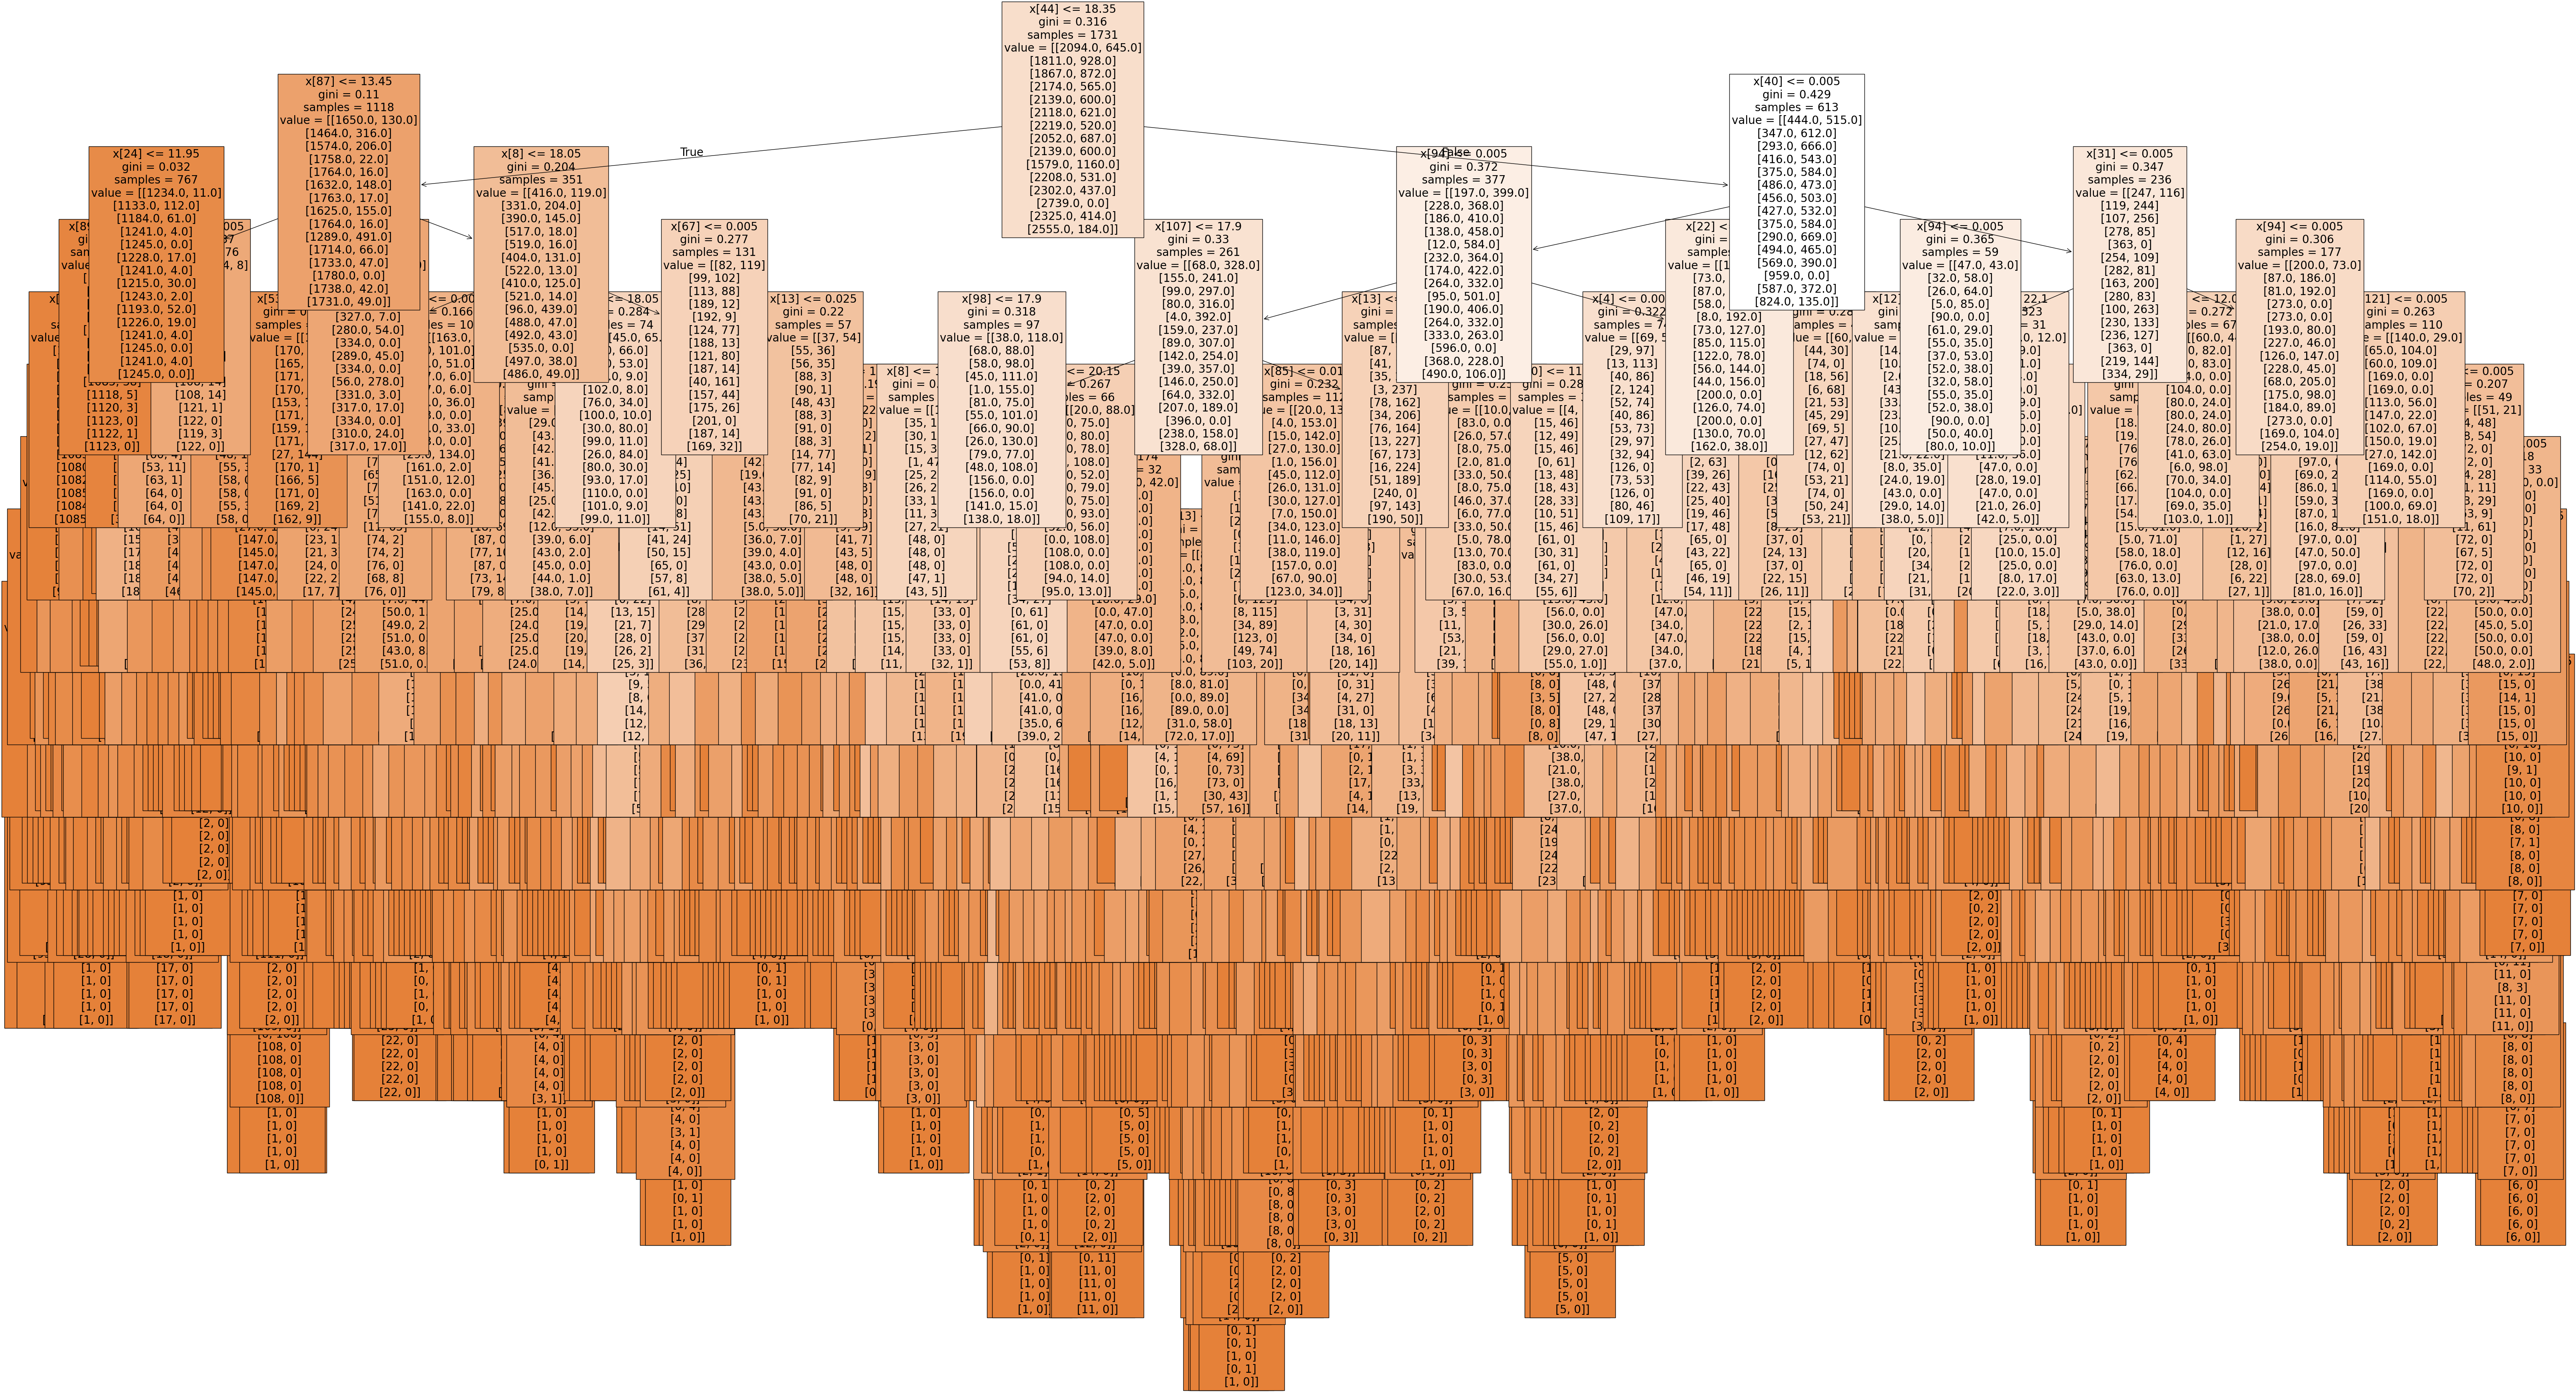

In [53]:
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[15], fontsize = 20, filled=True);

In [54]:
fig.savefig(os.path.join(path, 'grid_parameters_random_forest_1990s.png'),bbox_inches='tight')

### Feature Importances

In [59]:
# Retrieve feature importances from the trained model

newarray = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray

(135,)


array([0.00183536, 0.00211099, 0.00194082, 0.0026112 , 0.02270418,
       0.00270918, 0.0033011 , 0.00186941, 0.04356472, 0.00235152,
       0.00270698, 0.00210656, 0.00229873, 0.02988174, 0.00334315,
       0.00454161, 0.00181746, 0.00978506, 0.00176622, 0.00199995,
       0.00217932, 0.00227226, 0.0214318 , 0.00353821, 0.00410186,
       0.00172107, 0.01409694, 0.00142531, 0.00171482, 0.00226796,
       0.00201393, 0.0240945 , 0.00241642, 0.0018097 , 0.00212543,
       0.05354897, 0.00147852, 0.00189529, 0.00184263, 0.00197518,
       0.03587597, 0.00486928, 0.01429873, 0.00190322, 0.07526043,
       0.00150293, 0.00222498, 0.00263078, 0.00327512, 0.010703  ,
       0.00301542, 0.00231763, 0.00197193, 0.0143215 , 0.00168536,
       0.00199422, 0.00181843, 0.00252308, 0.01187333, 0.00233916,
       0.00256894, 0.00207362, 0.03810975, 0.00247056, 0.00166659,
       0.00244286, 0.0024564 , 0.03401664, 0.00256734, 0.00848789,
       0.00160871, 0.02231089, 0.00309608, 0.00206061, 0.00204

In [61]:
# Reshape newarray

newarray = newarray.reshape(-1,15,9)
print(newarray.shape)
newarray

(1, 15, 9)


array([[[0.00183536, 0.00211099, 0.00194082, 0.0026112 , 0.02270418,
         0.00270918, 0.0033011 , 0.00186941, 0.04356472],
        [0.00235152, 0.00270698, 0.00210656, 0.00229873, 0.02988174,
         0.00334315, 0.00454161, 0.00181746, 0.00978506],
        [0.00176622, 0.00199995, 0.00217932, 0.00227226, 0.0214318 ,
         0.00353821, 0.00410186, 0.00172107, 0.01409694],
        [0.00142531, 0.00171482, 0.00226796, 0.00201393, 0.0240945 ,
         0.00241642, 0.0018097 , 0.00212543, 0.05354897],
        [0.00147852, 0.00189529, 0.00184263, 0.00197518, 0.03587597,
         0.00486928, 0.01429873, 0.00190322, 0.07526043],
        [0.00150293, 0.00222498, 0.00263078, 0.00327512, 0.010703  ,
         0.00301542, 0.00231763, 0.00197193, 0.0143215 ],
        [0.00168536, 0.00199422, 0.00181843, 0.00252308, 0.01187333,
         0.00233916, 0.00256894, 0.00207362, 0.03810975],
        [0.00247056, 0.00166659, 0.00244286, 0.0024564 , 0.03401664,
         0.00256734, 0.00848789, 0.0016087

In [63]:
# Collapse this shape into one observation for each weather station

sumarray = np.sum(newarray[0], axis=1)
sumarray

array([0.08264695, 0.05883281, 0.05310764, 0.09141703, 0.13939925,
       0.0419633 , 0.06498589, 0.07802788, 0.14692888, 0.08343488,
       0.04305124, 0.04344191, 0.01708401, 0.03245873, 0.02321958])

In [65]:
# Convert the set of unique stations to a list

unique_stations_list = list(unique_stations)

In [67]:
important = pd.Series(sumarray, index = unique_stations_list)
important = important.sort_values(ascending = False)
important

DEBILT        0.146929
KASSEL        0.139399
LJUBLJANA     0.091417
DUSSELDORF    0.083435
MUNCHENB      0.082647
HEATHROW      0.078028
BELGRADE      0.064986
MADRID        0.058833
STOCKHOLM     0.053108
SONNBLICK     0.043442
OSLO          0.043051
BASEL         0.041963
MAASTRICHT    0.032459
BUDAPEST      0.023220
VALENTIA      0.017084
dtype: float64

In [69]:
# Create a df to associate weather stations with their importances

df_importance = pd.DataFrame({
    'Weather Station': unique_stations_list,
    'Importance': sumarray
})

df_importance = df_importance.sort_values(by='Importance', ascending = False)

['MUNCHENB', 'MADRID', 'STOCKHOLM', 'LJUBLJANA', 'KASSEL', 'BASEL', 'BELGRADE', 'HEATHROW', 'DEBILT', 'DUSSELDORF', 'OSLO', 'SONNBLICK', 'VALENTIA', 'MAASTRICHT', 'BUDAPEST']


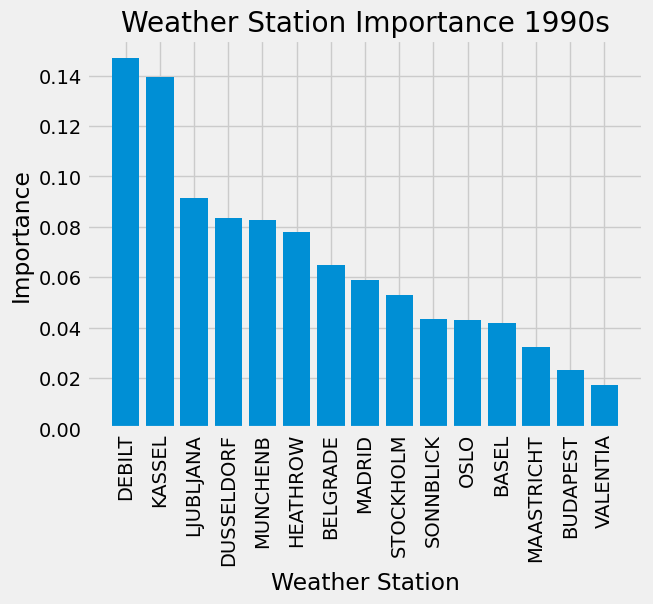

In [75]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
print(unique_stations_list)

plt.bar(df_importance['Weather Station'], df_importance['Importance'], orientation = 'vertical')
plt.xticks(rotation='vertical')
plt.xlabel('Weather Station')
plt.ylabel('Importance')
plt.title('Weather Station Importance 1990s')

plt.savefig(os.path.join(path,'1990s_feauture_importances.png'), bbox_inches='tight')

plt.show()